Saved lifespans to: rq2a/topic_lifespans.csv
   Mean Lifespan (months)  Median Lifespan (months)  Total Topics
0                   61.51                      68.0            84


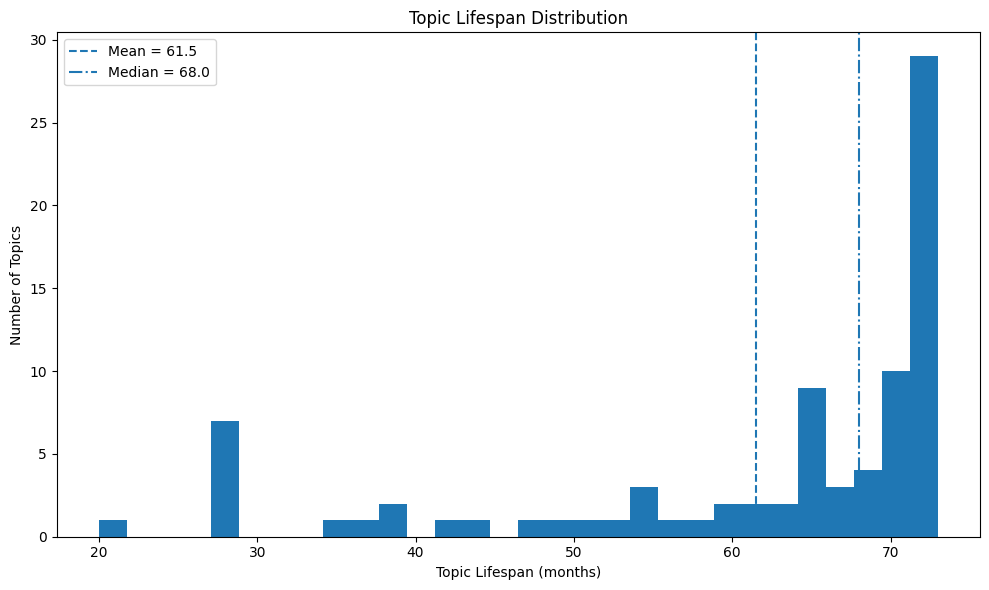

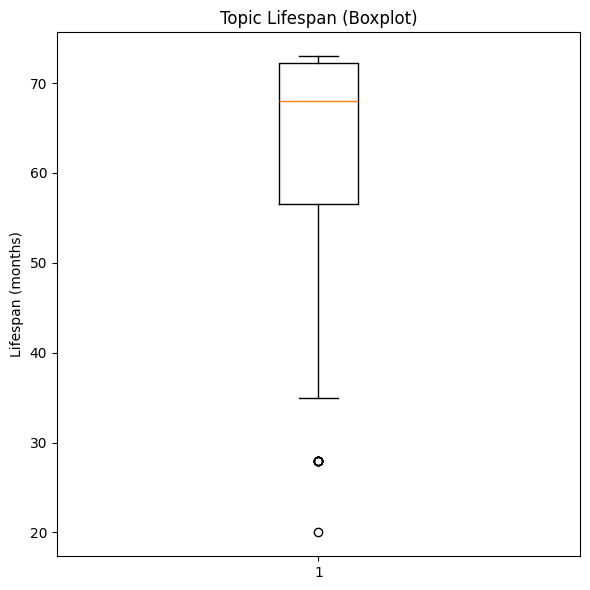

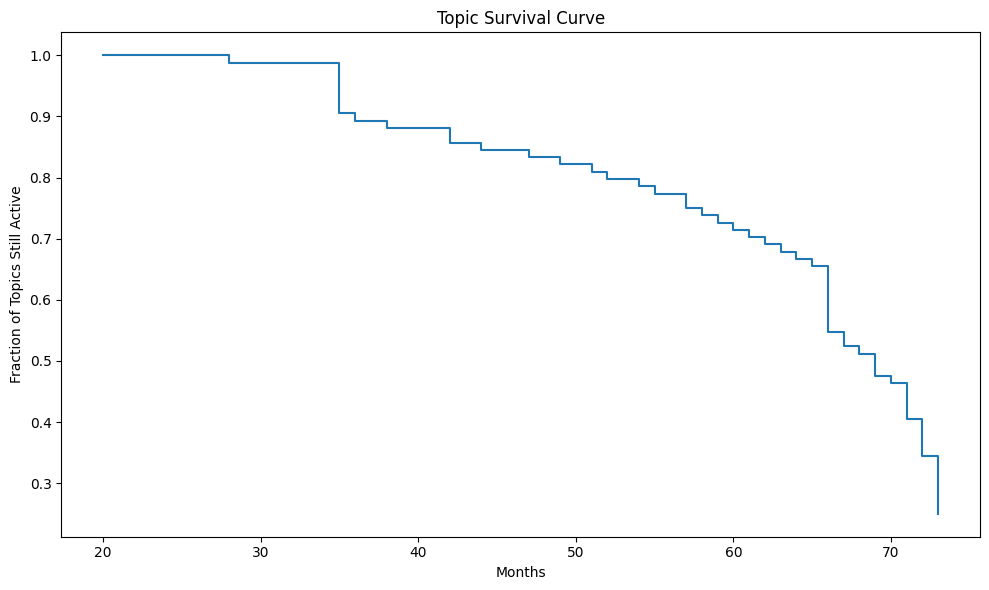

/tmp/ipykernel_3456424/2838280851.py:213: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Marketplace", "Forum"])


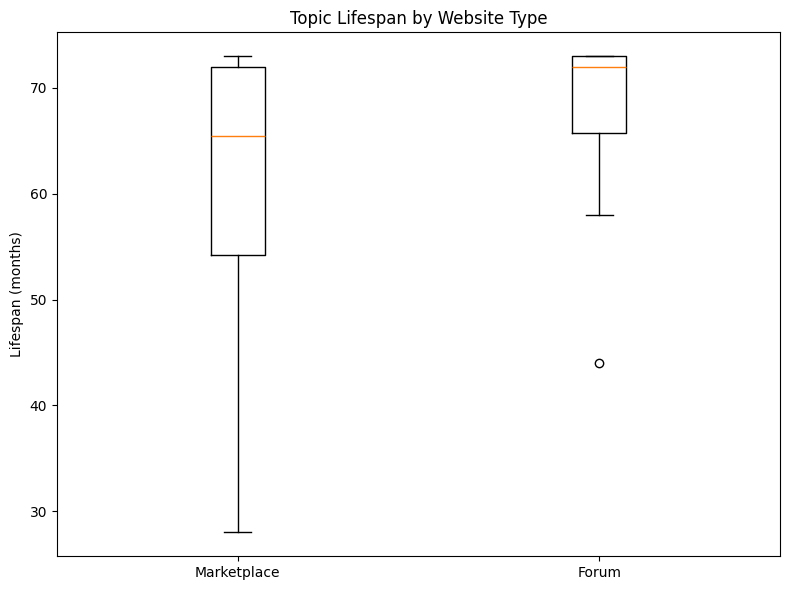


All outputs saved in: /home/darknet/2026-01-27_201419_domain_with_snapshots/rq2a

Files created:
- topic_lifespans.csv
- lifespan_summary_stats.csv
- lifespan_histogram.pdf
- lifespan_boxplot.pdf
- lifespan_survival_curve.pdf
- lifespan_market_vs_forum.pdf


,Topic,min,max,lifespan_months,site_type
0,0,2020-01,2026-01,73,Marketplace
1,1,2020-05,2026-01,69,Marketplace
2,2,2020-01,2026-01,73,Marketplace
3,3,2020-01,2026-01,73,Forum
4,4,2020-01,2026-01,73,Forum
5,5,2020-01,2026-01,73,Marketplace
6,6,2020-03,2026-01,71,Other
7,7,2020-02,2026-01,72,Other
8,8,2020-01,2026-01,73,Marketplace
9,9,2020-01,2026-01,73,Other


In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from bertopic import BERTopic
from pathlib import Path

# -------------------------
# Fix for BERTopic loading
# -------------------------
class IdentityReducer:
    def fit(self, X, y=None): return self
    def transform(self, X): return X
    def fit_transform(self, X, y=None): return X

# -------------------------
# PATHS
# -------------------------
JSONL_PATH = Path("preprocessed_from_disk.jsonl")
MODEL_PATH = Path("./DarkBERT/output_darkbert__900_90/bertopic_model")
WEBSITE_TYPES = Path("website_type_overview_improved_min4snapshots.csv")

OUT_DIR = Path("./rq2a")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Figures
FIG_HIST = OUT_DIR / "lifespan_histogram.pdf"
FIG_BOX = OUT_DIR / "lifespan_boxplot.pdf"
FIG_SURV = OUT_DIR / "lifespan_survival_curve.pdf"
FIG_SPLIT = OUT_DIR / "lifespan_market_vs_forum.pdf"

# Data
CSV_LIFESPANS = OUT_DIR / "topic_lifespans.csv"
CSV_STATS = OUT_DIR / "lifespan_summary_stats.csv"

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# -------------------------
# FILTERING (same as training)
# -------------------------
DOC_FIELD_PRIMARY = "preprocessed_trafilatura"
DOC_FIELD_FALLBACK = "preprocessed_content"

def load_filtered_metadata(path):
    rows = []

    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            try:
                rec = json.loads(line)
            except:
                continue

            text = rec.get(DOC_FIELD_PRIMARY, "")
            if not (isinstance(text, str) and text.strip()):
                text = rec.get(DOC_FIELD_FALLBACK, "")
                if not (isinstance(text, str) and text.strip()):
                    continue

            rows.append({
                "created_at": rec.get("created_at"),
                "domain_url": rec.get("domain_url"),
            })

    return pd.DataFrame(rows)

# -------------------------
# LOAD DATA
# -------------------------
topic_model = BERTopic.load(MODEL_PATH)
topics = topic_model.topics_

meta_df = load_filtered_metadata(JSONL_PATH)

if len(meta_df) != len(topics):
    raise ValueError("Mismatch after filtering")

meta_df["Topic"] = topics

meta_df = meta_df[(meta_df["Topic"] != -1) & (meta_df["created_at"].notna())]

meta_df["datetime"] = pd.to_datetime(meta_df["created_at"], unit="ms", errors="coerce")
meta_df = meta_df[meta_df["datetime"].notna()]

meta_df["month"] = meta_df["datetime"].dt.to_period("M")

# -------------------------
# LIFESPANS
# -------------------------
lifespans = (
    meta_df.groupby("Topic")["month"]
    .agg(["min", "max"])
    .reset_index()
)

lifespans["lifespan_months"] = (
    (lifespans["max"] - lifespans["min"]).apply(lambda x: x.n) + 1
)

lifespans.to_csv(CSV_LIFESPANS, index=False)

print("Saved lifespans to:", CSV_LIFESPANS)

# -------------------------
# BASIC STATS
# -------------------------
mean_life = lifespans["lifespan_months"].mean()
median_life = lifespans["lifespan_months"].median()

stats_df = pd.DataFrame([{
    "Mean Lifespan (months)": round(mean_life, 2),
    "Median Lifespan (months)": round(median_life, 2),
    "Total Topics": len(lifespans)
}])

stats_df.to_csv(CSV_STATS, index=False)

print(stats_df)

# =========================
# 1) HISTOGRAM
# =========================
plt.figure(figsize=(10, 6))
plt.hist(lifespans["lifespan_months"], bins=30)

plt.axvline(mean_life, linestyle="--", label=f"Mean = {mean_life:.1f}")
plt.axvline(median_life, linestyle="-.", label=f"Median = {median_life:.1f}")

plt.xlabel("Topic Lifespan (months)")
plt.ylabel("Number of Topics")
plt.title("Topic Lifespan Distribution")
plt.legend()
plt.tight_layout()

plt.savefig(FIG_HIST, bbox_inches="tight")
plt.show()

# =========================
# 2) BOXPLOT
# =========================
plt.figure(figsize=(6, 6))
plt.boxplot(lifespans["lifespan_months"], vert=True)

plt.ylabel("Lifespan (months)")
plt.title("Topic Lifespan (Boxplot)")
plt.tight_layout()

plt.savefig(FIG_BOX, bbox_inches="tight")
plt.show()

# =========================
# 3) SURVIVAL CURVE
# =========================
lifespan_counts = lifespans["lifespan_months"].value_counts().sort_index()

total_topics = len(lifespans)
remaining = total_topics

survival_x = []
survival_y = []

for t in sorted(lifespan_counts.index):
    survival_x.append(t)
    survival_y.append(remaining / total_topics)
    remaining -= lifespan_counts[t]

plt.figure(figsize=(10, 6))
plt.step(survival_x, survival_y, where="post")

plt.xlabel("Months")
plt.ylabel("Fraction of Topics Still Active")
plt.title("Topic Survival Curve")
plt.tight_layout()

plt.savefig(FIG_SURV, bbox_inches="tight")
plt.show()

# =========================
# 4) MARKETPLACE vs FORUM
# =========================
website_df = pd.read_csv(WEBSITE_TYPES)

meta_with_type = meta_df.merge(
    website_df[["domain_url", "site_type"]],
    on="domain_url",
    how="left"
)

topic_types = (
    meta_with_type.groupby(["Topic", "site_type"])
    .size()
    .reset_index(name="Count")
)

topic_types = topic_types.sort_values("Count", ascending=False)
topic_types = topic_types.drop_duplicates("Topic")

lifespans = lifespans.merge(
    topic_types[["Topic", "site_type"]],
    on="Topic",
    how="left"
)

plot_df = lifespans[lifespans["site_type"].isin(["Marketplace", "Forum"])]

plt.figure(figsize=(8, 6))

data = [
    plot_df[plot_df["site_type"] == "Marketplace"]["lifespan_months"],
    plot_df[plot_df["site_type"] == "Forum"]["lifespan_months"]
]

plt.boxplot(data, labels=["Marketplace", "Forum"])

plt.ylabel("Lifespan (months)")
plt.title("Topic Lifespan by Website Type")
plt.tight_layout()

plt.savefig(FIG_SPLIT, bbox_inches="tight")
plt.show()

# -------------------------
# FINAL OUTPUT SUMMARY
# -------------------------
print("\nAll outputs saved in:", OUT_DIR.resolve())
print("\nFiles created:")
print("-", CSV_LIFESPANS.name)
print("-", CSV_STATS.name)
print("-", FIG_HIST.name)
print("-", FIG_BOX.name)
print("-", FIG_SURV.name)
print("-", FIG_SPLIT.name)

display(lifespans.head(20))

[INFO] Filtered metadata rows kept: 7,381,762
[INFO] Skipped empty rows: 4,021,876 | Bad JSON: 0
[INFO] Topic assignments in model: 7,381,762
[INFO] Grouped topic-label rows: 84


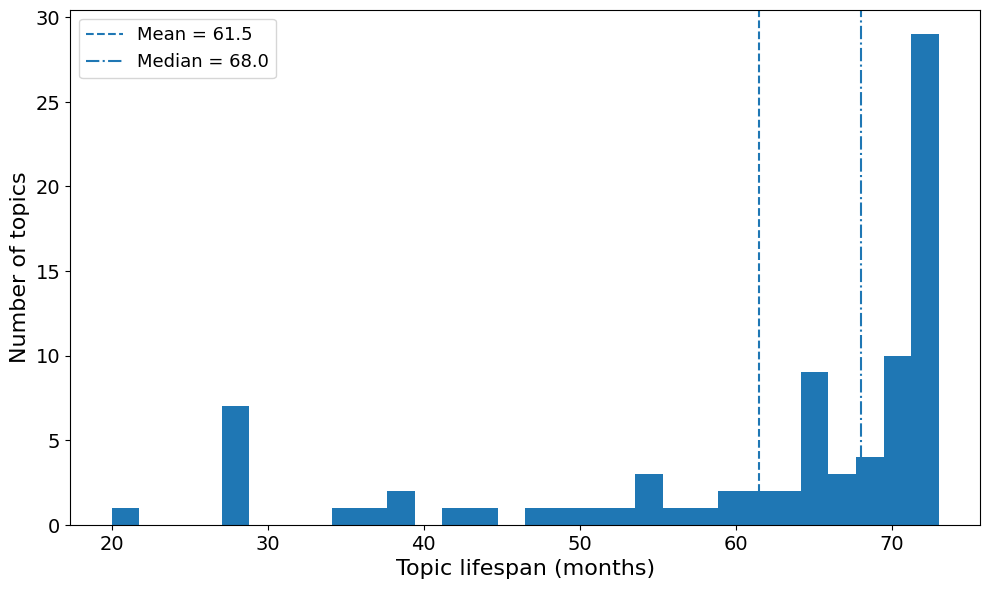

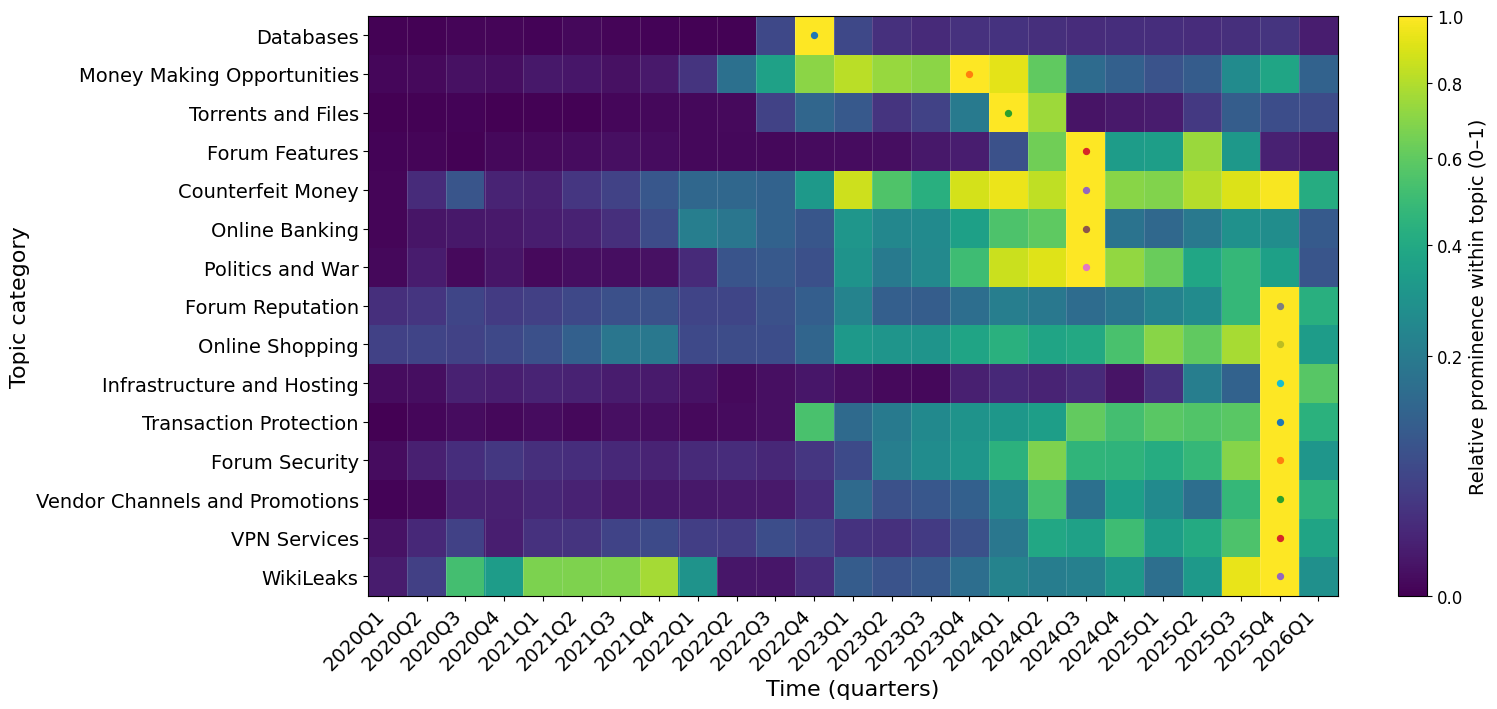

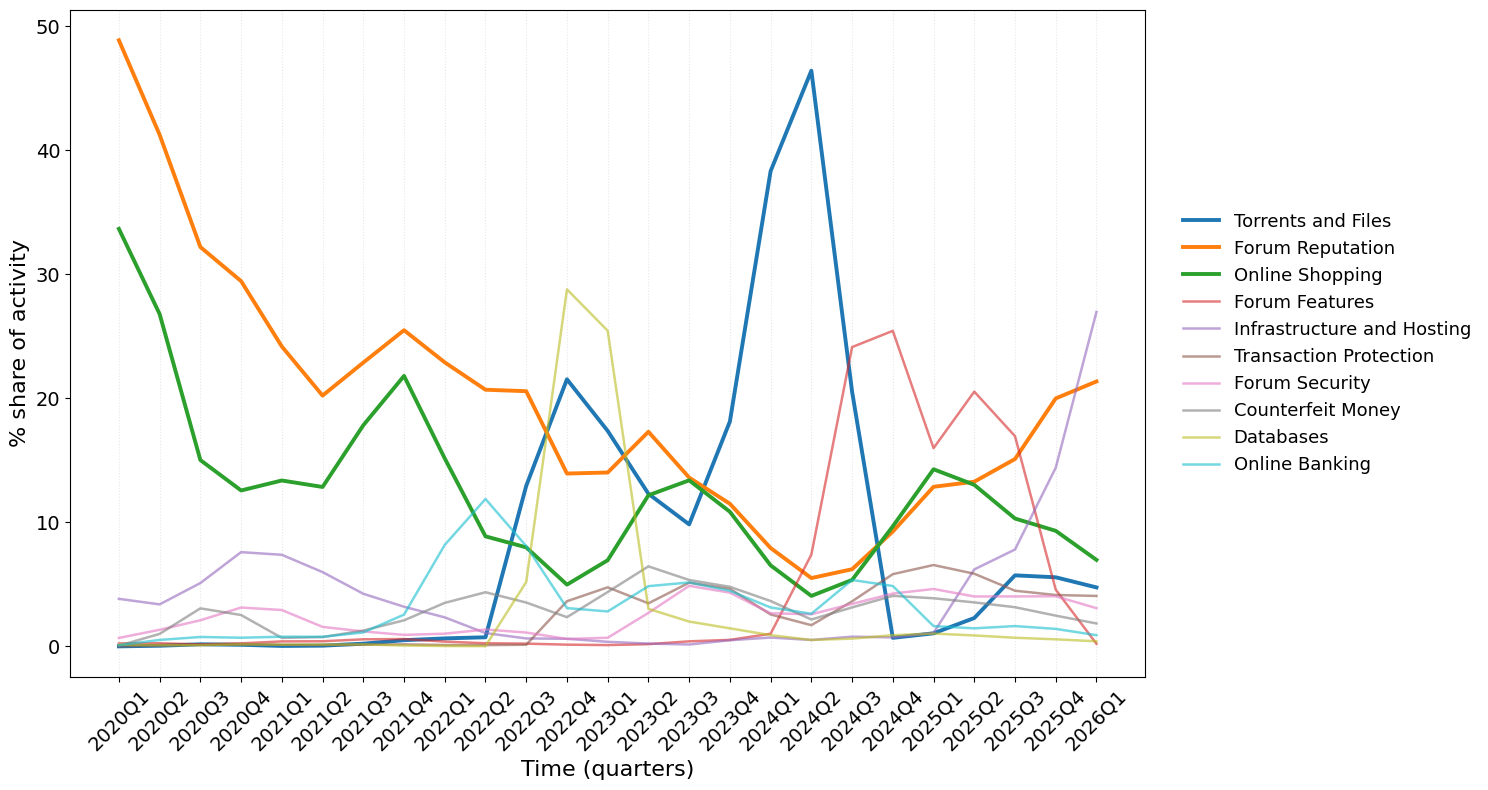

Saved lifespan histogram PDF to: /home/darknet/2026-01-27_201419_domain_with_snapshots/rq2a/topic_lifespan_distribution.pdf
Saved lifespan histogram PNG to: /home/darknet/2026-01-27_201419_domain_with_snapshots/rq2a/topic_lifespan_distribution.png
Saved heatmap PDF to: /home/darknet/2026-01-27_201419_domain_with_snapshots/rq2a/topic_temporal_prevalence_heatmap_peak_sorted.pdf
Saved heatmap PNG to: /home/darknet/2026-01-27_201419_domain_with_snapshots/rq2a/topic_temporal_prevalence_heatmap_peak_sorted.png
Saved line chart PDF to: /home/darknet/2026-01-27_201419_domain_with_snapshots/rq2a/topic_temporal_prevalence_lines_top10.pdf
Saved line chart PNG to: /home/darknet/2026-01-27_201419_domain_with_snapshots/rq2a/topic_temporal_prevalence_lines_top10.png
Saved lifespan table to: /home/darknet/2026-01-27_201419_domain_with_snapshots/rq2a/topic_lifespans.csv
Saved long temporal table to: /home/darknet/2026-01-27_201419_domain_with_snapshots/rq2a/topic_temporal_prevalence_long.csv
Saved wide

,Topic,Slope,Trend,Max_Percent,Mean_Percent
0,Online Banking,0.012246,Bursting,12.689310,3.168092
1,Databases,-0.015061,Bursting,47.201700,2.942022
2,Online Shopping,-0.502929,Declining,33.659509,11.996372
3,Forum Reputation,-0.888803,Declining,48.862916,19.059822
4,Forum Features,0.629939,Emerging,35.023119,4.850211
5,Torrents and Files,0.518766,Emerging,52.175093,8.927029
6,Infrastructure and Hosting,0.339903,Emerging,30.157047,4.759085
7,Transaction Protection,0.258450,Emerging,7.143057,2.548678
8,Forum Security,0.117787,Emerging,5.333833,2.568240
9,Counterfeit Money,0.070897,Emerging,6.748477,2.999712



Topic order:


,Final,Count
0,Torrents and Files,1026851
1,Forum Reputation,903883
2,Online Shopping,558270
3,Forum Features,524089
4,Infrastructure and Hosting,461151
5,Transaction Protection,243077
6,Forum Security,204509
7,Counterfeit Money,197892
8,Databases,192833
9,Online Banking,175989



Lifespan sample:


,Topic,first_seen,last_seen,first_period,last_period,first_month,last_month,lifespan_months,Final
0,0,2020-01-01 14:52:40,2026-01-30 19:08:59,2020Q1,2026Q1,2020-01,2026-01,73,Forum Reputation
1,1,2020-05-22 02:58:52,2026-01-30 14:42:42,2020Q2,2026Q1,2020-05,2026-01,69,Torrents and Files
2,2,2020-01-02 15:50:00,2026-01-30 18:35:18,2020Q1,2026Q1,2020-01,2026-01,73,Online Shopping
3,3,2020-01-12 00:01:34,2026-01-30 18:16:10,2020Q1,2026Q1,2020-01,2026-01,73,Forum Features
4,4,2020-01-18 06:14:29,2026-01-30 17:36:06,2020Q1,2026Q1,2020-01,2026-01,73,Infrastructure and Hosting
5,5,2020-01-02 15:50:59,2026-01-30 18:14:40,2020Q1,2026Q1,2020-01,2026-01,73,Forum Security
6,6,2020-03-15 17:12:45,2026-01-30 15:56:02,2020Q1,2026Q1,2020-03,2026-01,71,Databases
7,7,2020-02-04 11:34:33,2026-01-30 18:15:07,2020Q1,2026Q1,2020-02,2026-01,72,Online Banking
8,8,2020-01-30 22:17:43,2026-01-30 15:55:54,2020Q1,2026Q1,2020-01,2026-01,73,Politics and War
9,9,2020-01-18 06:03:54,2026-01-30 18:08:04,2020Q1,2026Q1,2020-01,2026-01,73,Money Making Opportunities



Peak-sorted heatmap matrix sample:


Period,2020Q1,2020Q2,2020Q3,2020Q4,2021Q1,2021Q2,2021Q3,2021Q4,2022Q1,2022Q2,...,2023Q4,2024Q1,2024Q2,2024Q3,2024Q4,2025Q1,2025Q2,2025Q3,2025Q4,2026Q1
Final_plot,,,,,,,,,,,,,,,,,,,,,
Databases,0.000104,0.000096,0.000348,0.000466,0.000200,0.001000,0.000429,0.000207,0.000052,0.000081,...,0.029505,0.030149,0.026032,0.023789,0.024492,0.024389,0.024019,0.025907,0.032378,0.010573
Money Making Opportunities,0.000560,0.001308,0.003363,0.002709,0.006539,0.006072,0.003410,0.007567,0.031761,0.164316,...,1.000000,0.925876,0.601681,0.146474,0.116628,0.084727,0.106259,0.265950,0.382532,0.123120
Torrents and Files,0.000000,0.000054,0.000223,0.000023,0.000046,0.000120,0.000559,0.001040,0.000930,0.001158,...,0.197381,1.000000,0.751241,0.004761,0.007638,0.009617,0.038584,0.109877,0.072786,0.068699
Forum Features,0.000175,0.000364,0.000114,0.000895,0.001158,0.001905,0.002787,0.002175,0.000976,0.000902,...,0.009910,0.078868,0.642525,1.000000,0.340658,0.347781,0.744390,0.320246,0.012892,0.005884
Counterfeit Money,0.000335,0.022422,0.089521,0.014930,0.012917,0.034724,0.052952,0.094498,0.136938,0.135037,...,0.888839,0.947551,0.831749,1.000000,0.701465,0.685473,0.808991,0.907683,0.981883,0.416518
Online Banking,0.000328,0.005716,0.006580,0.007354,0.010570,0.014529,0.026528,0.069491,0.212791,0.181916,...,0.355912,0.550838,0.597672,1.000000,0.172239,0.138774,0.191562,0.288385,0.273499,0.099741
Politics and War,0.000788,0.008846,0.001226,0.005562,0.001401,0.002715,0.002321,0.003285,0.020846,0.087238,...,0.506263,0.857625,0.910046,1.000000,0.725935,0.622668,0.383989,0.475782,0.358238,0.088640
Forum Reputation,0.026735,0.034112,0.058572,0.042193,0.047983,0.061338,0.078005,0.080058,0.056837,0.057521,...,0.157756,0.213334,0.188085,0.150880,0.179425,0.228806,0.266914,0.476792,1.000000,0.430519
Online Shopping,0.050602,0.055533,0.052918,0.061907,0.076427,0.116541,0.181868,0.189686,0.064182,0.070448,...,0.375953,0.437929,0.376771,0.397298,0.542443,0.702408,0.601231,0.772556,1.000000,0.339354



Line chart matrix sample:


Period,2020Q1,2020Q2,2020Q3,2020Q4,2021Q1,2021Q2,2021Q3,2021Q4,2022Q1,2022Q2,...,2023Q4,2024Q1,2024Q2,2024Q3,2024Q4,2025Q1,2025Q2,2025Q3,2025Q4,2026Q1
Final,,,,,,,,,,,,,,,,,,,,,
Torrents and Files,0.000000,0.051310,0.164591,0.128153,0.033679,0.057201,0.215324,0.496691,0.642009,0.731795,...,18.129323,38.315776,46.412388,20.543885,0.686017,1.052089,2.284963,5.724653,5.568739,4.752250
Forum Reputation,48.862916,41.243909,32.196566,29.447699,24.176637,20.220391,22.878011,25.489424,22.896655,20.691104,...,11.497388,7.928132,5.506754,6.218224,9.257674,12.865319,13.273619,15.105094,19.990959,21.355794
Online Shopping,33.659509,26.791150,15.019989,12.568756,13.372786,12.851906,17.825889,21.804552,15.150961,8.869242,...,10.851025,6.530657,4.066749,5.356266,9.677101,14.278190,13.022581,10.306363,9.313878,6.971647
Forum Features,0.235571,0.249725,0.154074,0.241905,0.399483,0.410892,0.567185,0.590397,0.383113,0.250136,...,0.522714,1.016769,7.399453,24.127915,25.438203,15.980594,20.535944,16.946815,4.568905,0.208671
Infrastructure and Hosting,3.832563,3.384714,5.103849,7.596222,7.382672,5.986891,4.240997,3.193654,2.337062,1.071270,...,0.493164,0.711902,0.513819,0.782642,0.723977,1.086384,6.203066,7.808726,14.405816,26.962888
Transaction Protection,0.000000,0.065970,0.158417,0.145325,0.127061,0.107676,0.127639,0.165030,0.109056,0.099786,...,4.637075,2.572990,1.707592,3.629654,5.821421,6.556881,5.854773,4.486448,4.139914,4.065691
Forum Security,0.679532,1.336639,2.103643,3.130962,2.927982,1.570370,1.202242,0.924730,1.022025,1.357817,...,4.330715,2.667220,2.589710,3.419510,4.255342,4.625230,4.022051,4.026434,4.040307,3.080196
Counterfeit Money,0.054363,1.006951,3.064405,2.525826,0.682550,0.748646,1.275881,2.099617,3.505091,4.362241,...,4.799464,3.656167,2.163973,3.139586,4.073554,3.876426,3.544497,3.156872,2.478055,1.845806
Databases,0.126846,0.095186,0.092961,0.165299,0.132312,0.138491,0.157353,0.069126,0.028267,0.016181,...,1.452915,0.904792,0.515942,0.622533,0.896985,1.031752,0.879759,0.694620,0.566099,0.408563


In [7]:
import json
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from matplotlib.colors import PowerNorm
from bertopic import BERTopic
from pathlib import Path

# -------------------------
# Fix for BERTopic loading
# -------------------------
class IdentityReducer:
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X

    def fit_transform(self, X, y=None):
        return X


# -------------------------
# PATHS
# -------------------------
JSONL_PATH = Path("preprocessed_from_disk.jsonl")
MODEL_PATH = Path("./DarkBERT/output_darkbert__900_90/bertopic_model")
LABELS_PATH = Path("./DarkBERT/original_run_darkbert_900_90/final_labeling.csv")

OUT_DIR = Path("./rq2a")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Figures
FIG_LIFESPAN_HIST_PDF = OUT_DIR / "topic_lifespan_distribution.pdf"
FIG_LIFESPAN_HIST_PNG = OUT_DIR / "topic_lifespan_distribution.png"

FIG_HEATMAP_PDF = OUT_DIR / "topic_temporal_prevalence_heatmap_peak_sorted.pdf"
FIG_HEATMAP_PNG = OUT_DIR / "topic_temporal_prevalence_heatmap_peak_sorted.png"

FIG_LINES_PDF = OUT_DIR / "topic_temporal_prevalence_lines_top10.pdf"
FIG_LINES_PNG = OUT_DIR / "topic_temporal_prevalence_lines_top10.png"

# Tables
OUT_LIFESPANS = OUT_DIR / "topic_lifespans.csv"
OUT_LONG = OUT_DIR / "topic_temporal_prevalence_long.csv"
OUT_WIDE_COUNTS = OUT_DIR / "topic_temporal_prevalence_wide_counts.csv"
OUT_WIDE_NORM = OUT_DIR / "topic_temporal_prevalence_wide_row_normalized.csv"
OUT_WIDE_NORM_PEAK = OUT_DIR / "topic_temporal_prevalence_wide_peak_sorted.csv"
OUT_TRENDS = OUT_DIR / "topic_temporal_prevalence_trends.csv"
OUT_TOPICS = OUT_DIR / "topic_temporal_prevalence_top_topics.csv"

# -------------------------
# SETTINGS
# -------------------------
PERIOD_MODE = "Q"              # "M", "Q", or "4M"
HEATMAP_TOP_N = 15
LINE_TOP_N = 10
LINE_SMOOTH_WINDOW = 2
MAX_LABEL_LEN = 30

# Heatmap appearance
HEATMAP_CMAP = "viridis"
HEATMAP_POWER_GAMMA = 0.55
SHOW_PEAK_MARKERS = True

DOC_FIELD_PRIMARY = "preprocessed_trafilatura"
DOC_FIELD_FALLBACK = "preprocessed_content"

# -------------------------
# FONT SIZES (+2)
# -------------------------
AXIS_LABEL_FONTSIZE = 16
X_TICK_FONTSIZE = 14
Y_TICK_FONTSIZE = 14
LEGEND_FONTSIZE = 13
CBAR_LABEL_FONTSIZE = 14
CBAR_TICK_FONTSIZE = 12

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


# -------------------------
# HELPERS
# -------------------------
def detect_delimiter(path: Path):
    with open(path, "r", encoding="utf-8-sig") as f:
        line = f.readline()
    return ";" if line.count(";") > line.count(",") else ","


def load_grouped_labels(path: Path):
    rows = []
    delim = detect_delimiter(path)

    with open(path, "r", encoding="utf-8-sig") as f:
        reader = csv.DictReader(f, delimiter=delim)

        for r in reader:
            tids = (r.get("Topic_ID") or "").split(",")
            final_label = (r.get("Final") or "").strip()

            for t in tids:
                t = t.strip()
                if t.isdigit():
                    rows.append({
                        "Topic": int(t),
                        "Final": final_label
                    })

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("No rows parsed from final_labeling.csv")
    return df


def load_filtered_metadata_from_jsonl(path: Path, primary_field: str, fallback_field: str):
    rows = []
    bad_json = 0
    skipped_empty = 0

    with path.open("r", encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                bad_json += 1
                continue

            text = rec.get(primary_field, "")
            if isinstance(text, str) and text.strip():
                pass
            else:
                text = rec.get(fallback_field, "")
                if not (isinstance(text, str) and text.strip()):
                    skipped_empty += 1
                    continue

            rows.append({
                "created_at": rec.get("created_at"),
                "domain_url": rec.get("domain_url"),
                "snapshot_id": rec.get("snapshot_id"),
            })

    print(f"[INFO] Filtered metadata rows kept: {len(rows):,}")
    print(f"[INFO] Skipped empty rows: {skipped_empty:,} | Bad JSON: {bad_json:,}")
    return pd.DataFrame(rows)


def build_period_column(dt_series, mode="Q"):
    if mode == "M":
        return dt_series.dt.to_period("M").astype(str)
    elif mode == "Q":
        return dt_series.dt.to_period("Q").astype(str)
    elif mode == "4M":
        years = dt_series.dt.year
        months = dt_series.dt.month
        bin_start = (((months - 1) // 4) * 4) + 1
        return years.astype(str) + "-" + bin_start.astype(str).str.zfill(2)
    else:
        raise ValueError("PERIOD_MODE must be one of: 'M', 'Q', '4M'")


def shorten(label, max_len=30):
    label = str(label)
    return label if len(label) <= max_len else label[:max_len - 3] + "..."


def add_period_gridlines(ax, n_cols):
    for x in range(n_cols):
        ax.axvline(x - 0.5, color="white", linewidth=0.6, alpha=0.18)


xlabel = {
    "M": "Time (months)",
    "Q": "Time (quarters)",
    "4M": "Time (4-month periods)"
}[PERIOD_MODE]


# -------------------------
# LOAD MODEL + FILTERED DATA + LABELS
# -------------------------
topic_model = BERTopic.load(MODEL_PATH)
topics = topic_model.topics_

meta_df = load_filtered_metadata_from_jsonl(
    JSONL_PATH,
    primary_field=DOC_FIELD_PRIMARY,
    fallback_field=DOC_FIELD_FALLBACK
)

labels_df = load_grouped_labels(LABELS_PATH)

print(f"[INFO] Topic assignments in model: {len(topics):,}")
print(f"[INFO] Grouped topic-label rows: {len(labels_df):,}")

if len(meta_df) != len(topics):
    raise ValueError(
        f"Mismatch after training-style filtering: "
        f"{len(meta_df):,} filtered rows vs {len(topics):,} topic assignments."
    )


# -------------------------
# ALIGN FINAL TOPICS WITH FILTERED METADATA
# -------------------------
meta_df = meta_df.copy()
meta_df["Topic"] = topics

meta_df = meta_df[meta_df["Topic"] != -1].copy()
meta_df = meta_df[meta_df["created_at"].notna()].copy()

meta_df["datetime"] = pd.to_datetime(meta_df["created_at"], unit="ms", errors="coerce")
meta_df = meta_df[meta_df["datetime"].notna()].copy()

meta_df["Period"] = build_period_column(meta_df["datetime"], PERIOD_MODE)

# merge grouped final labels
df = meta_df.merge(labels_df, on="Topic", how="left")
df["Final"] = df["Final"].fillna("Unlabeled")


# =========================================================
# 4.3.1 Topic Lifespan Distribution
# =========================================================
lifespans = (
    df.groupby("Topic")["datetime"]
    .agg(first_seen="min", last_seen="max")
    .reset_index()
)

lifespans["first_period"] = build_period_column(
    lifespans["first_seen"].dt.to_period("D").dt.to_timestamp(), PERIOD_MODE
)
lifespans["last_period"] = build_period_column(
    lifespans["last_seen"].dt.to_period("D").dt.to_timestamp(), PERIOD_MODE
)

lifespans["first_month"] = lifespans["first_seen"].dt.to_period("M")
lifespans["last_month"] = lifespans["last_seen"].dt.to_period("M")
lifespans["lifespan_months"] = (
    (lifespans["last_month"] - lifespans["first_month"]).apply(lambda x: x.n) + 1
)

topic_to_final = labels_df.drop_duplicates("Topic")[["Topic", "Final"]]
lifespans = lifespans.merge(topic_to_final, on="Topic", how="left")
lifespans["Final"] = lifespans["Final"].fillna("Unlabeled")

lifespans.to_csv(OUT_LIFESPANS, sep=";", index=False, encoding="utf-8-sig")

mean_life = lifespans["lifespan_months"].mean()
median_life = lifespans["lifespan_months"].median()

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(lifespans["lifespan_months"], bins=30)
ax.axvline(mean_life, linestyle="--", linewidth=1.5, label=f"Mean = {mean_life:.1f}")
ax.axvline(median_life, linestyle="-.", linewidth=1.5, label=f"Median = {median_life:.1f}")
ax.set_xlabel("Topic lifespan (months)", fontsize=AXIS_LABEL_FONTSIZE)
ax.set_ylabel("Number of topics", fontsize=AXIS_LABEL_FONTSIZE)
ax.tick_params(axis="x", labelsize=X_TICK_FONTSIZE)
ax.tick_params(axis="y", labelsize=Y_TICK_FONTSIZE)
ax.legend(fontsize=LEGEND_FONTSIZE)
plt.tight_layout()
plt.savefig(FIG_LIFESPAN_HIST_PDF, bbox_inches="tight")
plt.savefig(FIG_LIFESPAN_HIST_PNG, dpi=300, bbox_inches="tight")
plt.show()


# =========================================================
# 4.3.2 Temporal Prevalence
# =========================================================
long_df = (
    df.groupby(["Period", "Final"], as_index=False)
    .size()
    .rename(columns={"size": "Count"})
)

long_df["Percent"] = (
    long_df.groupby("Period")["Count"]
    .transform(lambda s: 100 * s / s.sum())
)

topic_order_df = (
    long_df.groupby("Final", as_index=False)["Count"]
    .sum()
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)

topic_order_df.to_csv(OUT_TOPICS, sep=";", index=False, encoding="utf-8-sig")

# Heatmap data: top N + Other Topics
heatmap_keep = set(topic_order_df.head(HEATMAP_TOP_N)["Final"])
heatmap_df = long_df.copy()
heatmap_df["Final_plot"] = heatmap_df["Final"].where(
    heatmap_df["Final"].isin(heatmap_keep),
    "Other Topics"
)

heatmap_df = (
    heatmap_df.groupby(["Period", "Final_plot"], as_index=False)["Count"]
    .sum()
)

heatmap_df["Percent"] = (
    heatmap_df.groupby("Period")["Count"]
    .transform(lambda s: 100 * s / s.sum())
)

wide_counts_heatmap = heatmap_df.pivot(index="Final_plot", columns="Period", values="Count").fillna(0)

heatmap_order = (
    heatmap_df.groupby("Final_plot", as_index=False)["Count"]
    .sum()
    .sort_values("Count", ascending=False)["Final_plot"]
    .tolist()
)
wide_counts_heatmap = wide_counts_heatmap.loc[[x for x in heatmap_order if x in wide_counts_heatmap.index]]

# row-normalize
row_max = wide_counts_heatmap.max(axis=1).replace(0, np.nan)
wide_norm_heatmap = wide_counts_heatmap.div(row_max, axis=0).fillna(0)

# improved heatmap: remove Other Topics and sort by peak timing
wide_norm_peak = wide_norm_heatmap.copy()
if "Other Topics" in wide_norm_peak.index:
    wide_norm_peak = wide_norm_peak.drop(index="Other Topics")

peak_positions = wide_norm_peak.values.argmax(axis=1)
wide_norm_peak = wide_norm_peak.assign(_peak_pos=peak_positions)
wide_norm_peak = wide_norm_peak.sort_values("_peak_pos").drop(columns="_peak_pos")

# line chart data: top N topics by total prevalence
line_topics = topic_order_df.head(LINE_TOP_N)["Final"].tolist()
wide_lines = (
    long_df[long_df["Final"].isin(line_topics)]
    .pivot(index="Final", columns="Period", values="Percent")
    .fillna(0)
)
wide_lines = wide_lines.loc[[x for x in line_topics if x in wide_lines.index]]

if LINE_SMOOTH_WINDOW > 1:
    wide_lines_plot = wide_lines.T.rolling(window=LINE_SMOOTH_WINDOW, min_periods=1).mean().T
else:
    wide_lines_plot = wide_lines.copy()

# trend classification
trend_rows = []
for topic in wide_lines.index:
    y = wide_lines.loc[topic].values.astype(float)
    x = np.arange(len(y))

    if len(np.unique(y)) == 1:
        slope = 0.0
    else:
        slope, _, _, _, _ = linregress(x, y)

    peak_count = int((y >= 0.9 * y.max()).sum()) if y.max() > 0 else 0

    if slope > 0.05:
        trend = "Emerging"
    elif slope < -0.05:
        trend = "Declining"
    elif peak_count <= 2 and y.max() > np.median(y) * 2:
        trend = "Bursting"
    else:
        trend = "Stable"

    trend_rows.append({
        "Topic": topic,
        "Slope": slope,
        "Trend": trend,
        "Max_Percent": y.max(),
        "Mean_Percent": y.mean()
    })

trend_df = pd.DataFrame(trend_rows).sort_values(["Trend", "Slope"], ascending=[True, False]).reset_index(drop=True)
trend_df.to_csv(OUT_TRENDS, sep=";", index=False, encoding="utf-8-sig")

# save tables
long_df.to_csv(OUT_LONG, sep=";", index=False, encoding="utf-8-sig")
wide_counts_heatmap.to_csv(OUT_WIDE_COUNTS, sep=";", encoding="utf-8-sig")
wide_norm_heatmap.to_csv(OUT_WIDE_NORM, sep=";", encoding="utf-8-sig")
wide_norm_peak.to_csv(OUT_WIDE_NORM_PEAK, sep=";", encoding="utf-8-sig")

# shortened labels for plotting
heatmap_labels = [shorten(x, MAX_LABEL_LEN) for x in wide_norm_peak.index]
line_labels = [shorten(x, MAX_LABEL_LEN) for x in wide_lines_plot.index]

# -------------------------
# PLOT 1: Peak-sorted, colorful heatmap
# -------------------------
n_topics_heatmap = len(wide_norm_peak)
fig_height_heatmap = max(7, min(12, 0.48 * n_topics_heatmap))

fig, ax = plt.subplots(figsize=(16, fig_height_heatmap))

im = ax.imshow(
    wide_norm_peak.values,
    aspect="auto",
    interpolation="nearest",
    cmap=HEATMAP_CMAP,
    norm=PowerNorm(gamma=HEATMAP_POWER_GAMMA, vmin=0, vmax=1)
)

ax.set_xticks(range(len(wide_norm_peak.columns)))
ax.set_xticklabels(wide_norm_peak.columns, rotation=45, ha="right", fontsize=X_TICK_FONTSIZE)

ax.set_yticks(range(len(wide_norm_peak.index)))
ax.set_yticklabels(heatmap_labels, fontsize=Y_TICK_FONTSIZE)

ax.set_xlabel(xlabel, fontsize=AXIS_LABEL_FONTSIZE)
ax.set_ylabel("Topic category", fontsize=AXIS_LABEL_FONTSIZE)

add_period_gridlines(ax, len(wide_norm_peak.columns))

if SHOW_PEAK_MARKERS:
    for i, row in enumerate(wide_norm_peak.values):
        peak = np.argmax(row)
        ax.scatter(peak, i, s=18, marker="o")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Relative prominence within topic (0–1)", fontsize=CBAR_LABEL_FONTSIZE)
cbar.ax.tick_params(labelsize=CBAR_TICK_FONTSIZE)

plt.tight_layout()
plt.savefig(FIG_HEATMAP_PDF, bbox_inches="tight")
plt.savefig(FIG_HEATMAP_PNG, dpi=300, bbox_inches="tight")
plt.show()

# -------------------------
# PLOT 2: Top-topic line chart
# -------------------------
fig, ax = plt.subplots(figsize=(15, 8))

for i, topic in enumerate(wide_lines_plot.index):
    lw = 2.8 if i < 3 else 1.8
    alpha = 1.0 if i < 3 else 0.6
    ax.plot(
        wide_lines_plot.columns,
        wide_lines_plot.loc[topic],
        linewidth=lw,
        alpha=alpha,
        label=line_labels[i]
    )

ax.tick_params(axis="x", labelrotation=45, labelsize=X_TICK_FONTSIZE)
ax.tick_params(axis="y", labelsize=Y_TICK_FONTSIZE)
ax.set_xlabel(xlabel, fontsize=AXIS_LABEL_FONTSIZE)
ax.set_ylabel("% share of activity", fontsize=AXIS_LABEL_FONTSIZE)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=LEGEND_FONTSIZE)
ax.grid(axis="x", linestyle=":", alpha=0.3)
plt.tight_layout()

plt.savefig(FIG_LINES_PDF, bbox_inches="tight")
plt.savefig(FIG_LINES_PNG, dpi=300, bbox_inches="tight")
plt.show()


# -------------------------
# OUTPUT SUMMARY
# -------------------------
print(f"Saved lifespan histogram PDF to: {FIG_LIFESPAN_HIST_PDF.resolve()}")
print(f"Saved lifespan histogram PNG to: {FIG_LIFESPAN_HIST_PNG.resolve()}")
print(f"Saved heatmap PDF to: {FIG_HEATMAP_PDF.resolve()}")
print(f"Saved heatmap PNG to: {FIG_HEATMAP_PNG.resolve()}")
print(f"Saved line chart PDF to: {FIG_LINES_PDF.resolve()}")
print(f"Saved line chart PNG to: {FIG_LINES_PNG.resolve()}")
print(f"Saved lifespan table to: {OUT_LIFESPANS.resolve()}")
print(f"Saved long temporal table to: {OUT_LONG.resolve()}")
print(f"Saved wide counts table to: {OUT_WIDE_COUNTS.resolve()}")
print(f"Saved row-normalized table to: {OUT_WIDE_NORM.resolve()}")
print(f"Saved peak-sorted table to: {OUT_WIDE_NORM_PEAK.resolve()}")
print(f"Saved trend table to: {OUT_TRENDS.resolve()}")
print(f"Saved topic order table to: {OUT_TOPICS.resolve()}")

print("\nTop topics used in heatmap:")
for i, topic in enumerate(topic_order_df.head(HEATMAP_TOP_N)["Final"], 1):
    print(f"{i:2d}. {topic}")

print("\nTop topics used in line chart:")
for i, topic in enumerate(line_topics, 1):
    print(f"{i:2d}. {topic}")

print("\nTrend classification:")
display(trend_df)

print("\nTopic order:")
display(topic_order_df.head(HEATMAP_TOP_N))

print("\nLifespan sample:")
display(lifespans.head(20))

print("\nPeak-sorted heatmap matrix sample:")
display(wide_norm_peak.head(10))

print("\nLine chart matrix sample:")
display(wide_lines_plot.head(10))

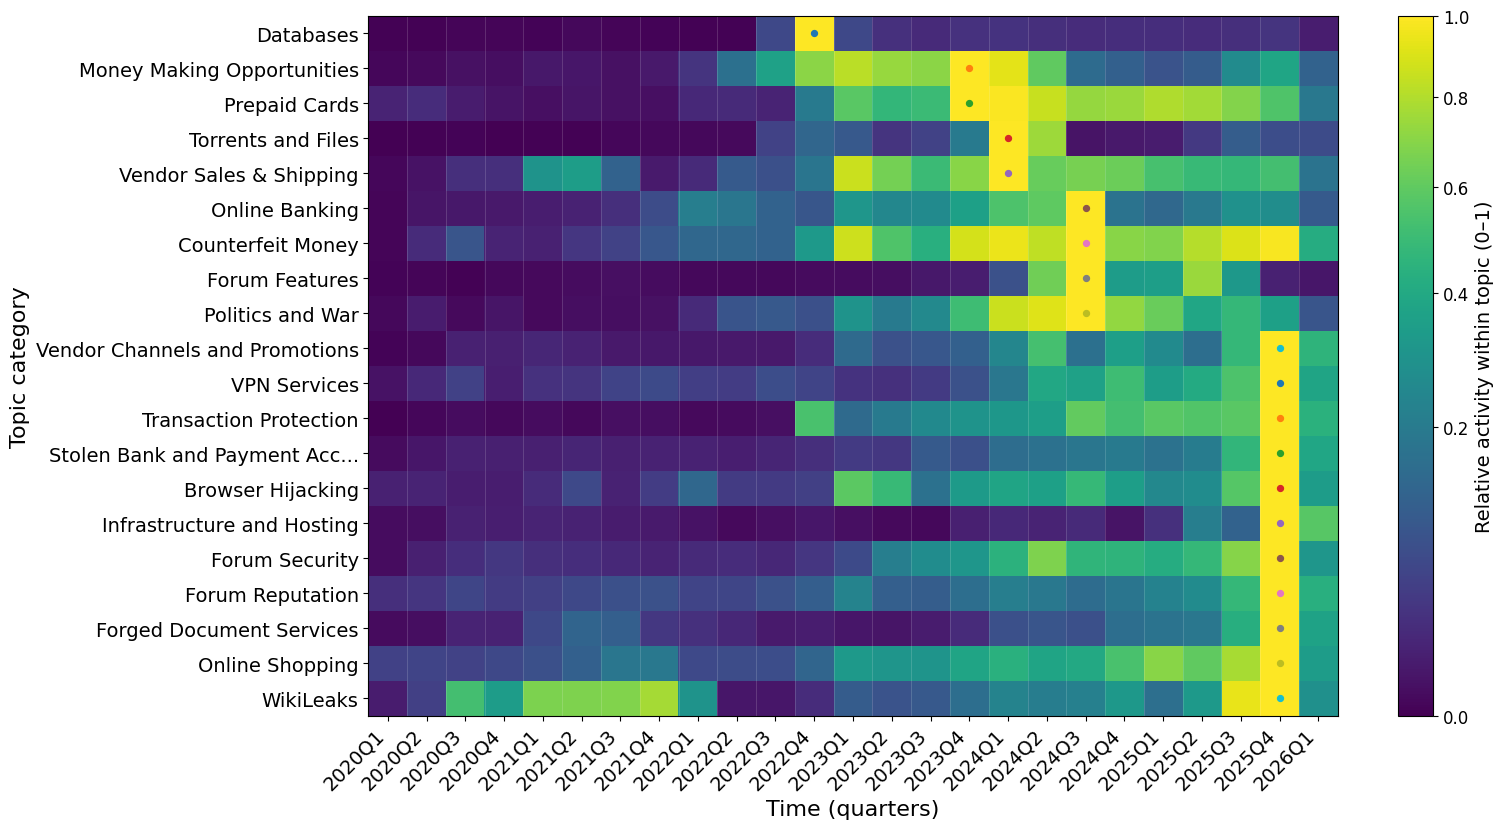

Saved lifecycle heatmap PDF to: /home/darknet/2026-01-27_201419_domain_with_snapshots/rq2a/topic_lifecycle_heatmap_lowrange_enhanced.pdf
Saved lifecycle heatmap PNG to: /home/darknet/2026-01-27_201419_domain_with_snapshots/rq2a/topic_lifecycle_heatmap_lowrange_enhanced.png
Saved lifecycle matrix to: /home/darknet/2026-01-27_201419_domain_with_snapshots/rq2a/topic_lifecycle_heatmap_lowrange_enhanced_matrix.csv


,Final,Count
0,Torrents and Files,1026851
1,Forum Reputation,903883
2,Online Shopping,558270
3,Forum Features,524089
4,Infrastructure and Hosting,461151
5,Transaction Protection,243077
6,Forum Security,204509
7,Counterfeit Money,197892
8,Databases,192833
9,Online Banking,175989


Period,2020Q1,2020Q2,2020Q3,2020Q4,2021Q1,2021Q2,2021Q3,2021Q4,2022Q1,2022Q2,...,2023Q4,2024Q1,2024Q2,2024Q3,2024Q4,2025Q1,2025Q2,2025Q3,2025Q4,2026Q1
Final_plot,,,,,,,,,,,,,,,,,,,,,
Databases,0.000104,0.000096,0.000348,0.000466,0.000200,0.001000,0.000429,0.000207,0.000052,0.000081,...,0.029505,0.030149,0.026032,0.023789,0.024492,0.024389,0.024019,0.025907,0.032378,0.010573
Money Making Opportunities,0.000560,0.001308,0.003363,0.002709,0.006539,0.006072,0.003410,0.007567,0.031761,0.164316,...,1.000000,0.925876,0.601681,0.146474,0.116628,0.084727,0.106259,0.265950,0.382532,0.123120
Prepaid Cards,0.015487,0.023193,0.009065,0.004457,0.003248,0.005515,0.003777,0.003097,0.019113,0.020926,...,1.000000,0.992597,0.855405,0.729470,0.745033,0.794289,0.762106,0.690715,0.555488,0.189998
Torrents and Files,0.000000,0.000054,0.000223,0.000023,0.000046,0.000120,0.000559,0.001040,0.000930,0.001158,...,0.197381,1.000000,0.751241,0.004761,0.007638,0.009617,0.038584,0.109877,0.072786,0.068699
Vendor Sales & Shipping,0.000701,0.004208,0.026453,0.026754,0.296493,0.343988,0.120942,0.008617,0.020741,0.100301,...,0.700401,1.000000,0.615531,0.660321,0.629760,0.536473,0.486774,0.478758,0.525752,0.173647
Online Banking,0.000328,0.005716,0.006580,0.007354,0.010570,0.014529,0.026528,0.069491,0.212791,0.181916,...,0.355912,0.550838,0.597672,1.000000,0.172239,0.138774,0.191562,0.288385,0.273499,0.099741
Counterfeit Money,0.000335,0.022422,0.089521,0.014930,0.012917,0.034724,0.052952,0.094498,0.136938,0.135037,...,0.888839,0.947551,0.831749,1.000000,0.701465,0.685473,0.808991,0.907683,0.981883,0.416518
Forum Features,0.000175,0.000364,0.000114,0.000895,0.001158,0.001905,0.002787,0.002175,0.000976,0.000902,...,0.009910,0.078868,0.642525,1.000000,0.340658,0.347781,0.744390,0.320246,0.012892,0.005884
Politics and War,0.000788,0.008846,0.001226,0.005562,0.001401,0.002715,0.002321,0.003285,0.020846,0.087238,...,0.506263,0.857625,0.910046,1.000000,0.725935,0.622668,0.383989,0.475782,0.358238,0.088640


In [8]:
import json
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from bertopic import BERTopic
from pathlib import Path

# -------------------------
# Fix for BERTopic loading
# -------------------------
class IdentityReducer:
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X
    def fit_transform(self, X, y=None):
        return X

# -------------------------
# PATHS
# -------------------------
JSONL_PATH = Path("preprocessed_from_disk.jsonl")
MODEL_PATH = Path("./DarkBERT/output_darkbert__900_90/bertopic_model")
LABELS_PATH = Path("./DarkBERT/original_run_darkbert_900_90/final_labeling.csv")

OUT_DIR = Path("./rq2a")
OUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_PDF = OUT_DIR / "topic_lifecycle_heatmap_lowrange_enhanced.pdf"
FIG_PNG = OUT_DIR / "topic_lifecycle_heatmap_lowrange_enhanced.png"
OUT_WIDE = OUT_DIR / "topic_lifecycle_heatmap_lowrange_enhanced_matrix.csv"

# -------------------------
# SETTINGS
# -------------------------
PERIOD_MODE = "Q"              # "M", "Q", or "4M"
HEATMAP_TOP_N = 20
MAX_LABEL_LEN = 30

# colorful + better low-range visibility
HEATMAP_CMAP = "viridis"
HEATMAP_POWER_GAMMA = 0.55

DOC_FIELD_PRIMARY = "preprocessed_trafilatura"
DOC_FIELD_FALLBACK = "preprocessed_content"

# -------------------------
# FONT SIZES (+2)
# -------------------------
AXIS_LABEL_FONTSIZE = 16
X_TICK_FONTSIZE = 14
Y_TICK_FONTSIZE = 14
CBAR_LABEL_FONTSIZE = 14
CBAR_TICK_FONTSIZE = 12

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# -------------------------
# HELPERS
# -------------------------
def detect_delimiter(path: Path):
    with open(path, "r", encoding="utf-8-sig") as f:
        line = f.readline()
    return ";" if line.count(";") > line.count(",") else ","

def load_grouped_labels(path: Path):
    rows = []
    delim = detect_delimiter(path)

    with open(path, "r", encoding="utf-8-sig") as f:
        reader = csv.DictReader(f, delimiter=delim)

        for r in reader:
            tids = (r.get("Topic_ID") or "").split(",")
            final_label = (r.get("Final") or "").strip()

            for t in tids:
                t = t.strip()
                if t.isdigit():
                    rows.append({
                        "Topic": int(t),
                        "Final": final_label
                    })

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("No rows parsed from final_labeling.csv")
    return df

def load_filtered_metadata_from_jsonl(path: Path, primary_field: str, fallback_field: str):
    rows = []

    with path.open("r", encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue

            text = rec.get(primary_field, "")
            if isinstance(text, str) and text.strip():
                pass
            else:
                text = rec.get(fallback_field, "")
                if not (isinstance(text, str) and text.strip()):
                    continue

            rows.append({
                "created_at": rec.get("created_at"),
            })

    return pd.DataFrame(rows)

def build_period_column(dt_series, mode="Q"):
    if mode == "M":
        return dt_series.dt.to_period("M").astype(str)
    elif mode == "Q":
        return dt_series.dt.to_period("Q").astype(str)
    elif mode == "4M":
        years = dt_series.dt.year
        months = dt_series.dt.month
        bin_start = (((months - 1) // 4) * 4) + 1
        return years.astype(str) + "-" + bin_start.astype(str).str.zfill(2)
    else:
        raise ValueError("PERIOD_MODE must be one of: 'M', 'Q', '4M'")

def shorten(label, max_len=30):
    label = str(label)
    return label if len(label) <= max_len else label[:max_len - 3] + "..."

def add_period_gridlines(ax, n_cols):
    for x in range(n_cols):
        ax.axvline(x - 0.5, color="white", linewidth=0.6, alpha=0.18)

xlabel = {
    "M": "Time (months)",
    "Q": "Time (quarters)",
    "4M": "Time (4-month periods)"
}[PERIOD_MODE]

# -------------------------
# LOAD MODEL + FILTERED DATA + LABELS
# -------------------------
topic_model = BERTopic.load(MODEL_PATH)
topics = topic_model.topics_

meta_df = load_filtered_metadata_from_jsonl(
    JSONL_PATH,
    primary_field=DOC_FIELD_PRIMARY,
    fallback_field=DOC_FIELD_FALLBACK
)

labels_df = load_grouped_labels(LABELS_PATH)

if len(meta_df) != len(topics):
    raise ValueError(
        f"Mismatch after training-style filtering: "
        f"{len(meta_df):,} filtered rows vs {len(topics):,} topic assignments."
    )

# -------------------------
# ALIGN TOPICS WITH METADATA
# -------------------------
meta_df = meta_df.copy()
meta_df["Topic"] = topics

meta_df = meta_df[meta_df["Topic"] != -1].copy()
meta_df = meta_df[meta_df["created_at"].notna()].copy()

meta_df["datetime"] = pd.to_datetime(meta_df["created_at"], unit="ms", errors="coerce")
meta_df = meta_df[meta_df["datetime"].notna()].copy()
meta_df["Period"] = build_period_column(meta_df["datetime"], PERIOD_MODE)

# -------------------------
# MERGE FINAL GROUPED LABELS
# -------------------------
df = meta_df.merge(labels_df, on="Topic", how="left")
df["Final"] = df["Final"].fillna("Unlabeled")

# -------------------------
# COUNTS BY PERIOD AND TOPIC
# -------------------------
long_df = (
    df.groupby(["Period", "Final"], as_index=False)
    .size()
    .rename(columns={"size": "Count"})
)

topic_order_df = (
    long_df.groupby("Final", as_index=False)["Count"]
    .sum()
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)

keep_topics = set(topic_order_df.head(HEATMAP_TOP_N)["Final"])

heatmap_df = long_df.copy()
heatmap_df["Final_plot"] = heatmap_df["Final"].where(
    heatmap_df["Final"].isin(keep_topics),
    "Other Topics"
)

heatmap_df = (
    heatmap_df.groupby(["Period", "Final_plot"], as_index=False)["Count"]
    .sum()
)

wide_counts = heatmap_df.pivot(index="Final_plot", columns="Period", values="Count").fillna(0)

# row-normalize: lifecycle pattern within each topic
row_max = wide_counts.max(axis=1).replace(0, np.nan)
wide_norm = wide_counts.div(row_max, axis=0).fillna(0)

# optional: remove "Other Topics" for cleaner lifecycle reading
if "Other Topics" in wide_norm.index:
    wide_norm = wide_norm.drop(index="Other Topics")

# sort by peak timing
peak_positions = wide_norm.values.argmax(axis=1)
wide_norm = wide_norm.assign(_peak_pos=peak_positions)
wide_norm = wide_norm.sort_values("_peak_pos").drop(columns="_peak_pos")

wide_norm.to_csv(OUT_WIDE, sep=";", encoding="utf-8-sig")

# -------------------------
# PLOT
# -------------------------
ylabels = [shorten(x, MAX_LABEL_LEN) for x in wide_norm.index]

n_topics = len(wide_norm)
fig_height = max(8, min(14, 0.42 * n_topics))

fig, ax = plt.subplots(figsize=(16, fig_height))

im = ax.imshow(
    wide_norm.values,
    aspect="auto",
    interpolation="nearest",
    cmap=HEATMAP_CMAP,
    norm=PowerNorm(gamma=HEATMAP_POWER_GAMMA, vmin=0, vmax=1)
)

ax.set_xticks(range(len(wide_norm.columns)))
ax.set_xticklabels(wide_norm.columns, rotation=45, ha="right", fontsize=X_TICK_FONTSIZE)

ax.set_yticks(range(len(wide_norm.index)))
ax.set_yticklabels(ylabels, fontsize=Y_TICK_FONTSIZE)

ax.set_xlabel(xlabel, fontsize=AXIS_LABEL_FONTSIZE)
ax.set_ylabel("Topic category", fontsize=AXIS_LABEL_FONTSIZE)

add_period_gridlines(ax, len(wide_norm.columns))

# mark each topic's peak period
for i, row in enumerate(wide_norm.values):
    peak = np.argmax(row)
    ax.scatter(peak, i, s=18, marker="o")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Relative activity within topic (0–1)", fontsize=CBAR_LABEL_FONTSIZE)
cbar.ax.tick_params(labelsize=CBAR_TICK_FONTSIZE)

plt.tight_layout()
plt.savefig(FIG_PDF, bbox_inches="tight")
plt.savefig(FIG_PNG, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved lifecycle heatmap PDF to: {FIG_PDF.resolve()}")
print(f"Saved lifecycle heatmap PNG to: {FIG_PNG.resolve()}")
print(f"Saved lifecycle matrix to: {OUT_WIDE.resolve()}")

display(topic_order_df.head(HEATMAP_TOP_N))
display(wide_norm.head(10))